In [1]:
import numpy as np
import tensorflow as tf
from pathlib import Path
from tensorflow.keras import layers, models, callbacks

# =========================
# CONFIG
# =========================
DATA_DIR = Path("/content/drive/MyDrive/lstm_data_new")
MODEL_DIR = Path("/content/drive/MyDrive/models/lstm_multi_final")

SEQ_LEN = 24
N_FEATURES = 12
EPOCHS = 40
BATCH_SIZE = 128

# =========================
# LOAD DATA
# =========================
X = np.load(DATA_DIR / "X.npy")
y = np.load(DATA_DIR / "y_multi.npy")  # shape (N, 3) → 1h, 3h, 6h

y_1h, y_3h, y_6h = y[:, 0], y[:, 1], y[:, 2]

split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train = {
    "q50_1h": y_1h[:split],
    "q50_3h": y_3h[:split],
    "q50_6h": y_6h[:split],
    "q90_1h": y_1h[:split],
    "q90_3h": y_3h[:split],
    "q90_6h": y_6h[:split],
}
y_val = {
    "q50_1h": y_1h[split:],
    "q50_3h": y_3h[split:],
    "q50_6h": y_6h[split:],
    "q90_1h": y_1h[split:],
    "q90_3h": y_3h[split:],
    "q90_6h": y_6h[split:],
}

# =========================
# QUANTILE LOSS
# =========================
def quantile_loss(q):
    def loss(y_true, y_pred):
        e = y_true - y_pred
        return tf.reduce_mean(tf.maximum(q * e, (q - 1) * e))
    return loss

# =========================
# MODEL
# =========================
inp = layers.Input(shape=(SEQ_LEN, N_FEATURES))

x = layers.LSTM(64, return_sequences=True)(inp)
x = layers.Dropout(0.2)(x)
x = layers.LSTM(32)(x)
x = layers.Dropout(0.2)(x)

outputs = {
    "q50_1h": layers.Dense(1)(x),
    "q50_3h": layers.Dense(1)(x),
    "q50_6h": layers.Dense(1)(x),
    "q90_1h": layers.Dense(1)(x),
    "q90_3h": layers.Dense(1)(x),
    "q90_6h": layers.Dense(1)(x),
}

model = models.Model(inputs=inp, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss={
        "q50_1h": quantile_loss(0.5),
        "q50_3h": quantile_loss(0.5),
        "q50_6h": quantile_loss(0.5),
        "q90_1h": quantile_loss(0.9),
        "q90_3h": quantile_loss(0.9),
        "q90_6h": quantile_loss(0.9),
    },
    loss_weights={
        "q50_1h": 0.5,
        "q50_3h": 1.0,
        "q50_6h": 1.5,
        "q90_1h": 1.0,
        "q90_3h": 1.5,
        "q90_6h": 2.0,
    }
)

model.summary()

# =========================
# CALLBACKS
# =========================
MODEL_DIR.mkdir(parents=True, exist_ok=True)

cb = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-5
    ),
    callbacks.ModelCheckpoint(
        MODEL_DIR / "lstm_multi_best.keras",
        save_best_only=True
    )
]

# =========================
# TRAIN
# =========================
model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=False,
    callbacks=cb
)

# =========================
# SAVE FINAL
# =========================
model.save(MODEL_DIR / "lstm_multi_final.keras")
print(" Saved LSTM (.keras)")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 24, 64)    │     19,712 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 64)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │         33 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,326 (126.27 KB)

 Trainable params: 32,326 (126.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
177/177 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 4.2650 - q50_1h_loss: 0.4153 - q50_3h_loss: 0.5444 - q50_6h_loss: 0.6466 - q90_1h_loss: 0.3736 - q90_3h_loss: 0.5522 - q90_6h_loss: 0.6706 - val_loss: 2.8168 - val_q50_1h_loss: 0.3498 - val_q50_3h_loss: 0.4693 - val_q50_6h_loss: 0.5742 - val_q90_1h_loss: 0.2530 - val_q90_3h_loss: 0.2982 - val_q90_6h_loss: 0.3083 - learning_rate: 0.0010
Epoch 2/40
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 2.9370 - q50_1h_loss: 0.3995 - q50_3h_loss: 0.5087 - q50_6h_loss: 0.5697 - q90_1h_loss: 0.2680 - q90_3h_loss: 0.3095 - q90_6h_loss: 0.3208 - val_loss: 2.7071 - val_q50_1h_loss: 0.3392 - val_q50_3h_loss: 0.4476 - val_q50_6h_loss: 0.5613 - val_q90_1h_loss: 0.2444 - val_q90_3h_loss: 0.2835 - val_q90_6h_loss: 0.2925 - learning_rate: 0.0010
Epoch 3/40
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 2.8133 - q50_1h_loss: 0.3838 - q50_3h_loss: 0.4842 - q50_6h_loss: 0.5501 - q90_1h_loss: 0.2544 - q90_3h_loss: 0.2961 - q90_6h_loss: 0.3068 -

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


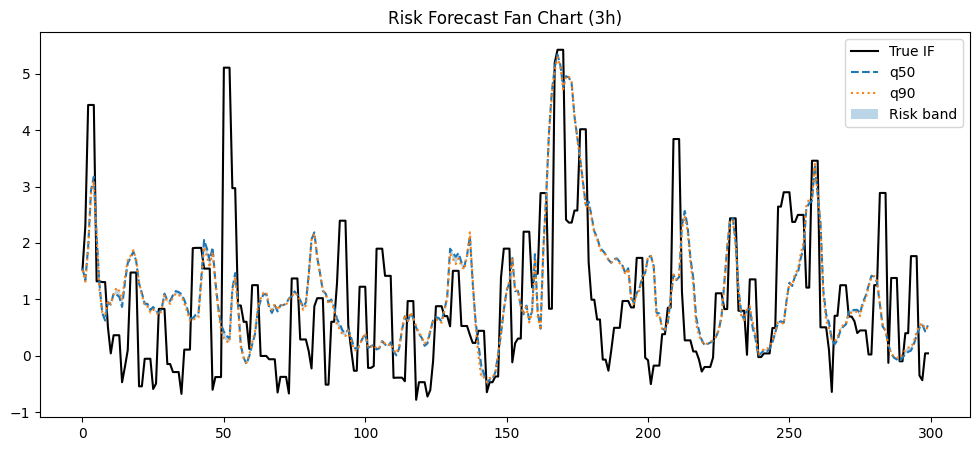

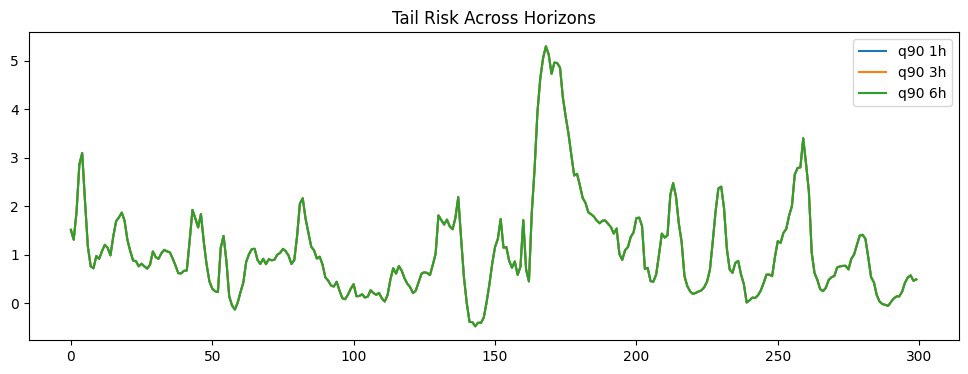

1h → q50 coverage: 0.824, q90 coverage: 0.826
3h → q50 coverage: 0.607, q90 coverage: 0.610
6h → q50 coverage: 0.375, q90 coverage: 0.380
Top 1% extreme-event recall (3h): 0.380


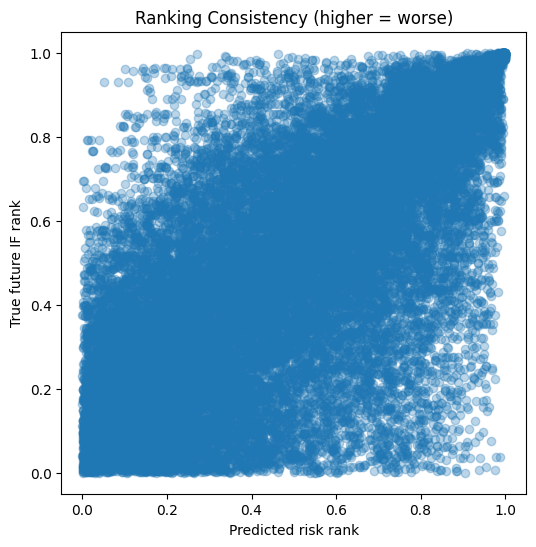

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from scipy.stats import rankdata

# =========================
# CONFIG
# =========================
DATA_DIR = Path("/content/drive/MyDrive/lstm_data_new")
MODEL_PATH = Path("/content/drive/MyDrive/models/lstm_multi/lstm_multi_final.keras")

HORIZON = "3h"  # change to "1h" or "6h" for other plots
N_PLOT = 300

# =========================
# LOAD
# =========================
X = np.load(DATA_DIR / "X.npy")
y = np.load(DATA_DIR / "y_multi.npy")
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

y_1h, y_3h, y_6h = y[:, 0], y[:, 1], y[:, 2]
true_map = {"1h": y_1h, "3h": y_3h, "6h": y_6h}
true_y = true_map[HORIZON]


# model.predict returns a dict of arrays (multi-output model)
pred = model.predict(X, batch_size=256)
# pred is a list of arrays
q50 = pred[0].ravel()   # first output
q90 = pred[1].ravel()   # second output


# =========================
# FAN CHART
# =========================
idx = slice(0, N_PLOT)

plt.figure(figsize=(12, 5))
plt.plot(true_y[idx], color="black", label="True IF")
plt.plot(q50[idx], "--", label="q50")
plt.plot(q90[idx], ":", label="q90")
plt.fill_between(np.arange(N_PLOT), q50[idx], q90[idx], alpha=0.3, label="Risk band")
plt.title(f"Risk Forecast Fan Chart ({HORIZON})")
plt.legend()
plt.show()

# =========================
# TAIL RISK ACROSS HORIZONS
# =========================
plt.figure(figsize=(12, 4))
for h in ["1h", "3h", "6h"]:
    plt.plot(pred[1].ravel()[:N_PLOT], label=f"q90 {h}")
plt.title("Tail Risk Across Horizons")
plt.legend()
plt.show()

# =========================
# QUANTILE COVERAGE
# =========================
for h in ["1h", "3h", "6h"]:
    q50_h = pred[0].ravel()
    q90_h = pred[1].ravel()
    y_h = true_map[h]

    cov50 = np.mean(y_h <= q50_h)
    cov90 = np.mean(y_h <= q90_h)
    print(f"{h} → q50 coverage: {cov50:.3f}, q90 coverage: {cov90:.3f}")

# =========================
# EXTREME EVENT RECALL (TOP 1%)
# =========================
thr = np.quantile(true_y, 0.99)
mask = true_y >= thr
recall = np.mean(q90[mask] >= thr)
print(f"Top 1% extreme-event recall ({HORIZON}): {recall:.3f}")

# =========================
# RANKING CONSISTENCY
# =========================
true_rank = rankdata(true_y, method="average")
pred_rank = rankdata(q90, method="average")

plt.figure(figsize=(6, 6))
plt.scatter(pred_rank / len(pred_rank), true_rank / len(true_rank), alpha=0.3)
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("Predicted risk rank")
plt.ylabel("True future IF rank")
plt.title("Ranking Consistency (higher = worse)")
plt.show()



Processing and plotting for coin: PEPE
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


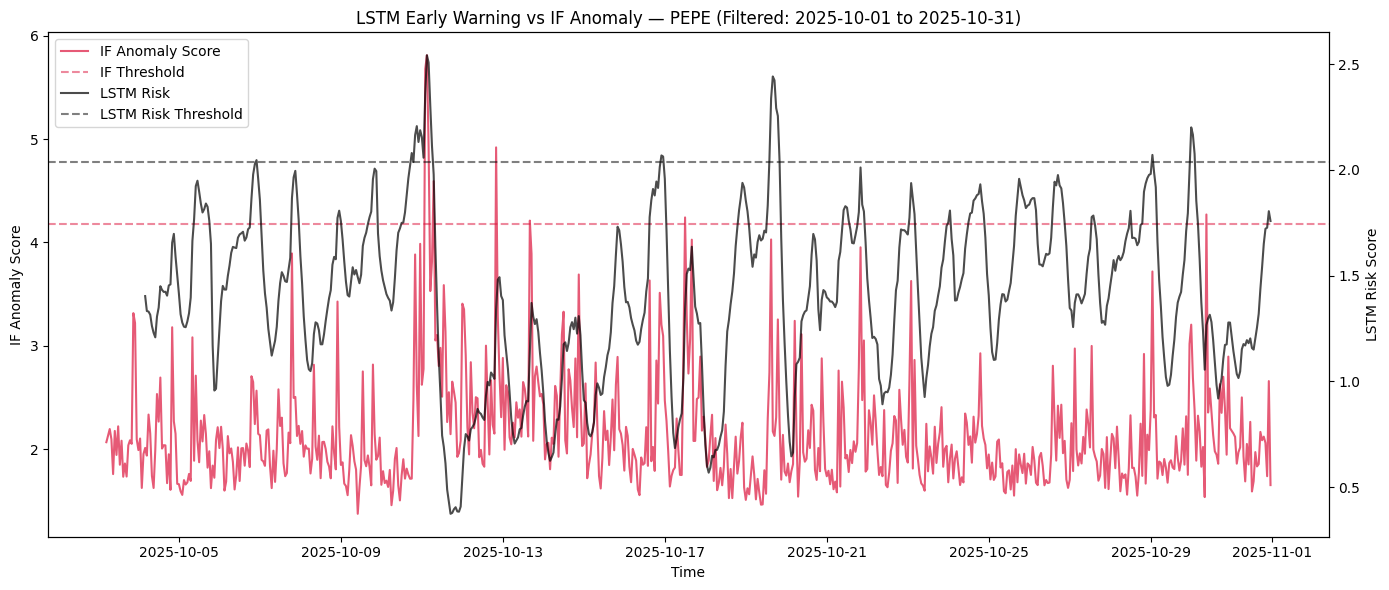


Processing and plotting for coin: SHIB
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


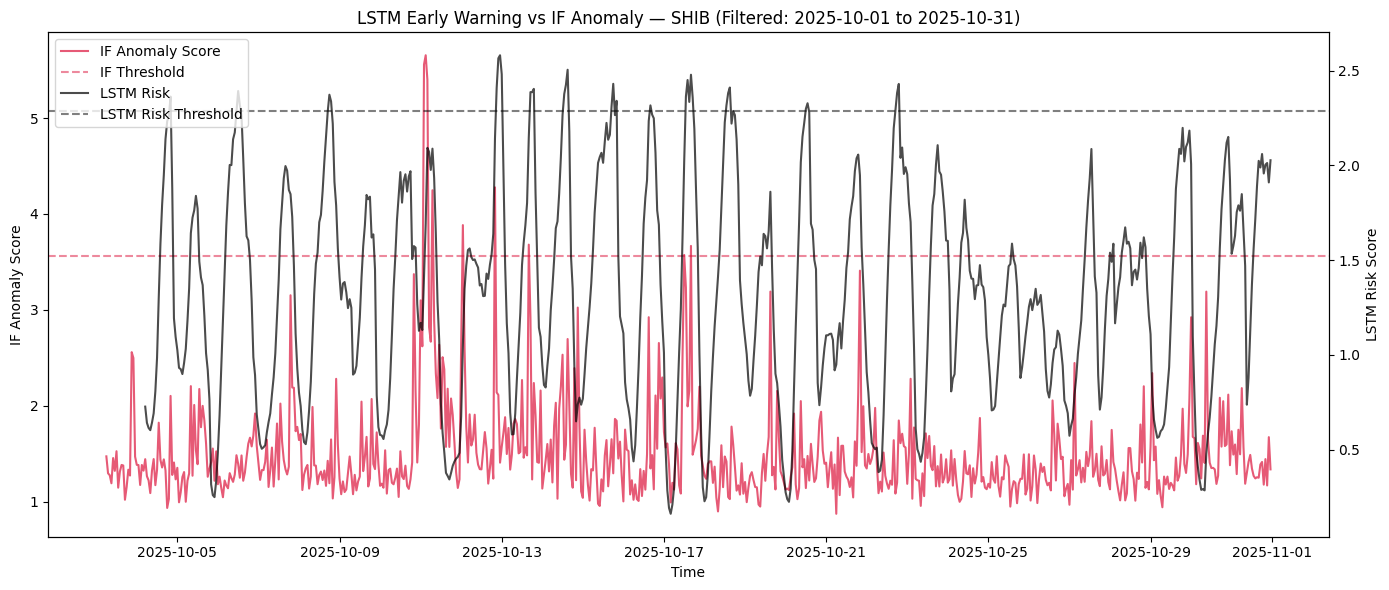


Processing and plotting for coin: DOGE
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


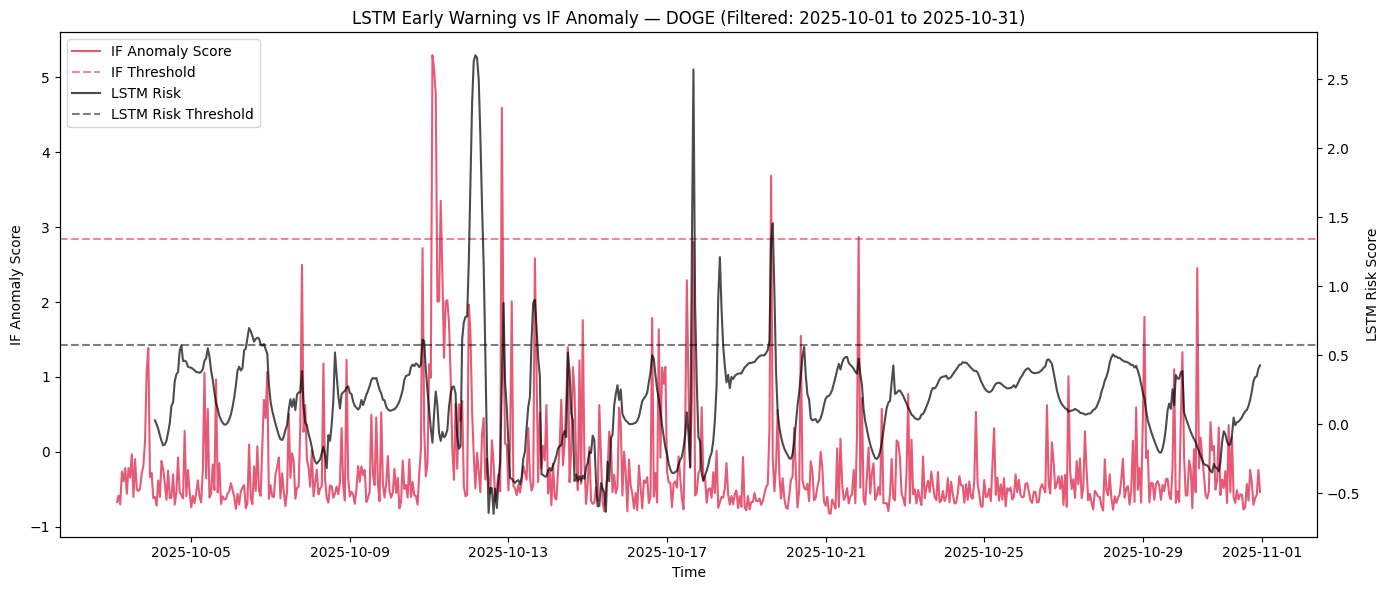

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from google.colab import files # Import files module for Colab uploads
import os # Import os module for path checks

# =========================
# CONFIG
# =========================
SOCIAL_MARKET_IF_CSV = Path("/content/drive/MyDrive/market_hourly_with_if (1).csv")
SOCIAL_FEATURES_CSV = Path("/content/drive/MyDrive/social_hourly_features (1).csv") # Added social features CSV path
LSTM_DATA_DIR = Path("/content/drive/MyDrive/lstm_data_new")
MODEL_PATH = Path("/content/drive/MyDrive/models/lstm_multi/lstm_multi_final.keras") # Corrected path based on previous cell

SEQ_LEN = 24
FUTURE_HORIZON = 3

COINS_TO_PLOT = ["PEPE", "SHIB", "DOGE"]   # change to any coins you want
RISK_PERCENTILE = 0.95 # top 5% risk

# Define the specific time region to focus on
PLOT_START_DATE = pd.to_datetime("2025-10-01 00:00:00+00:00")
PLOT_END_DATE = pd.to_datetime("2025-10-31 23:59:59+00:00")

FEATURE_COLS = [
    "hype_score",
    "coin_reveal_score",
    "entropy_mean",
    "msg_velocity",
    "return",
    "log_return",
    "hl_range",
    "if_score",
    "open_first",   # Added features to match N_FEATURES=12 in the model
    "high_max",
    "low_min",
    "close_last"
]

# =========================
# LOAD DATA (once for all coins)
# =========================

# Check if files exist, if not, prompt for upload
if not SOCIAL_MARKET_IF_CSV.exists():
    print(f"File not found: {SOCIAL_MARKET_IF_CSV}. Please upload it.")
    uploaded = files.upload()
    if SOCIAL_MARKET_IF_CSV.name not in uploaded:
        print(f"Error: {SOCIAL_MARKET_IF_CSV.name} was not uploaded. Please ensure you upload the correct file.")
        raise FileNotFoundError(f"Required file {SOCIAL_MARKET_IF_CSV} is missing.")
    print(f"{SOCIAL_MARKET_IF_CSV.name} uploaded successfully.")

if not SOCIAL_FEATURES_CSV.exists():
    print(f"File not found: {SOCIAL_FEATURES_CSV}. Please upload it.")
    uploaded = files.upload()
    if SOCIAL_FEATURES_CSV.name not in uploaded:
        print(f"Error: {SOCIAL_FEATURES_CSV.name} was not uploaded. Please ensure you upload the correct file.")
        raise FileNotFoundError(f"Required file {SOCIAL_FEATURES_CSV} is missing.")
    print(f"{SOCIAL_FEATURES_CSV.name} uploaded successfully.")

full_market_df = pd.read_csv(SOCIAL_MARKET_IF_CSV, parse_dates=["hour_ts"])
if full_market_df['hour_ts'].dt.tz is None:
    full_market_df['hour_ts'] = full_market_df['hour_ts'].dt.tz_localize('UTC')

full_social_df = pd.read_csv(SOCIAL_FEATURES_CSV, parse_dates=["hour_ts"])
if full_social_df['hour_ts'].dt.tz is None:
    full_social_df['hour_ts'] = full_social_df['hour_ts'].dt.tz_localize('UTC')


# =========================
# LOAD LSTM MODEL
# =========================
# Check if model file exists before loading
if not MODEL_PATH.exists():
    print(f"Error: Model file not found at expected path: {MODEL_PATH}")
    print("Please ensure the model training cell (XuPh4kXCtsss) has been run successfully to save the model.")
    raise FileNotFoundError(f"Model file not found at: {MODEL_PATH}")

model = tf.keras.models.load_model(MODEL_PATH, compile=False)


# =========================
# PROCESS AND PLOT FOR EACH COIN
# =========================
for COIN_TO_PLOT in COINS_TO_PLOT:
    print(f"\nProcessing and plotting for coin: {COIN_TO_PLOT}")

    df = full_market_df[full_market_df["coin"] == COIN_TO_PLOT].sort_values("hour_ts").reset_index(drop=True)
    social_df = full_social_df[full_social_df["coin"] == COIN_TO_PLOT].sort_values("hour_ts").reset_index(drop=True)

    if df.empty or social_df.empty:
        print(f"No data found for {COIN_TO_PLOT}. Skipping.")
        continue

    df = pd.merge(df, social_df.drop(columns=['coin'], errors='ignore'), on="hour_ts", how="left")

    # Calculate additional features
    df["return"] = df["close_last"].pct_change()
    df["log_return"] = np.log(df["close_last"]).diff()
    df["hl_range"] = (df["high_max"] - df["low_min"]) / df["close_last"]

    # Fill NaNs created by diff/pct_change (first row) and potentially merge (missing social data)
    df = df.fillna(0)

    # =========================
    # REBUILD SEQUENCES FOR THIS COIN
    # =========================
    X_coin = []

    # Validate that all FEATURE_COLS are present after merging and calculations
    missing_cols = [col for col in FEATURE_COLS if col not in df.columns]
    if missing_cols:
        print(f"Warning: Missing required feature columns in DataFrame for {COIN_TO_PLOT}: {missing_cols}. Skipping coin.")
        continue

    # Adjust loop range to ensure there are enough data points for sequence and future horizon
    if len(df) < SEQ_LEN + FUTURE_HORIZON:
        print(f"Not enough data for {COIN_TO_PLOT} to create sequences. Skipping coin.")
        continue

    for i in range(len(df) - SEQ_LEN - FUTURE_HORIZON):
        X_coin.append(
            df.loc[i:i+SEQ_LEN-1, FEATURE_COLS].values
        )

    X_coin = np.array(X_coin, dtype=np.float32)

    if X_coin.shape[0] == 0:
        print(f"No sequences generated for {COIN_TO_PLOT}. Skipping coin.")
        continue

    # =========================
    # PREDICT LSTM RISK
    # =========================
    pred_outputs = model.predict(X_coin)

    output_key = f"q50_{FUTURE_HORIZON}h"
    if isinstance(pred_outputs, dict):
        risk_scores = pred_outputs.get(output_key, pred_outputs[list(pred_outputs.keys())[0]]).ravel() # Fallback to first output
    elif isinstance(pred_outputs, list):
        try:
            # Try to find the index of the output key. Assumes model.output_names exists.
            output_index = model.output_names.index(output_key)
            risk_scores = pred_outputs[output_index].ravel()
        except (ValueError, AttributeError): # Handle if output_names doesn't exist or key not found
            print(f"Warning: Could not find output '{output_key}' in model outputs for {COIN_TO_PLOT}. Using first output.")
            risk_scores = pred_outputs[0].ravel() # Default to the first output
    else:
        risk_scores = pred_outputs.ravel() # For single output models, or if it's already an array

    risk_ts = df["hour_ts"].iloc[SEQ_LEN + FUTURE_HORIZON - 1 : len(df)].reset_index(drop=True)

    num_predictions = len(risk_scores)
    if len(risk_ts) > num_predictions:
        risk_ts = risk_ts.iloc[:num_predictions]
    elif num_predictions > len(risk_ts):
        risk_scores = risk_scores[:len(risk_ts)]

    risk_df = pd.DataFrame({
        "hour_ts": risk_ts,
        "lstm_risk": risk_scores
    })
    risk_df["hour_ts"] = risk_df["hour_ts"] - pd.Timedelta(hours=FUTURE_HORIZON)

    # =========================
    # MERGE WITH IF SCORES & FILTER BY DATE RANGE
    # =========================
    plot_df = df.merge(risk_df, on="hour_ts", how="left")
    plot_df = plot_df[(plot_df['hour_ts'] >= PLOT_START_DATE) & (plot_df['hour_ts'] <= PLOT_END_DATE)]

    if plot_df.empty:
        print(f"No data in the specified plot range for {COIN_TO_PLOT}. Skipping plot.")
        continue

    # =========================
    # THRESHOLDS
    # =========================
    # Only calculate thresholds if risk_scores is not empty
    if len(risk_scores) > 0:
        risk_threshold = np.quantile(risk_scores, RISK_PERCENTILE)
    else:
        risk_threshold = np.nan # Or some default value if no predictions

    if len(df["if_score"]) > 0:
        if_threshold = df["if_score"].quantile(0.99)
    else:
        if_threshold = np.nan

    # =========================
    # PLOT
    # =========================
    plt.figure(figsize=(14, 6))

    ax1 = plt.gca()
    ax2 = ax1.twinx()

    # IF score
    ax1.plot(
        plot_df["hour_ts"],
        plot_df["if_score"],
        label="IF Anomaly Score",
        alpha=0.7,
        color="crimson"
    )

    if not np.isnan(if_threshold):
        ax1.axhline(
            if_threshold,
            linestyle="--",
            alpha=0.5,
            label="IF Threshold",
            color="crimson"
        )

    # LSTM risk
    ax2.plot(
        plot_df["hour_ts"],
        plot_df["lstm_risk"],
        label="LSTM Risk",
        alpha=0.7,
        color="black"
    )

    if not np.isnan(risk_threshold):
        ax2.axhline(
            risk_threshold,
            linestyle="--",
            alpha=0.5,
            label="LSTM Risk Threshold",
            color="black"
        )

    # Labels
    ax1.set_xlabel("Time")
    ax1.set_ylabel("IF Anomaly Score")
    ax2.set_ylabel("LSTM Risk Score")

    plt.title(f"LSTM Early Warning vs IF Anomaly — {COIN_TO_PLOT} (Filtered: {PLOT_START_DATE.strftime('%Y-%m-%d')} to {PLOT_END_DATE.strftime('%Y-%m-%d')})")

    # Legend handling
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    plt.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.tight_layout()
    plt.show()